# Cuaderno 1: Análisis Exploratorio de Datos (EDA) y Preprocesamiento

En este primer cuaderno sentaremos las bases de nuestro sistema de mantenimiento predictivo. Trabajaremos con el dataset C-MAPSS de la NASA (específicamente los subconjuntos `train_FD001.txt` y `test_FD001.txt`), que simulan el comportamiento de motores turbofan comerciales. El objetivo principal de esta fase es transformar los datos crudos de los sensores en conjuntos de datos limpios, estructurados y optimizados, listos para entrenar y validar nuestros modelos de Inteligencia Artificial.

A lo largo de este documento, realizaremos las siguientes tareas fundamentales: 

* **Cálculo de la Variable Objetivo:** Generación manual de la variable RUL (Remaining Useful Life) para cada motor del conjunto de entrenamiento. 
* **Análisis Exploratorio y Estadístico:** Uso de Python y herramientas de R (ggplot2, LOESS) para entender distribuciones, varianzas operativas y correlaciones entre variables. 
* **Limpieza de Datos:** Eliminación de sensores constantes y tratamiento de la multicolinealidad para evitar variables redundantes. 
* **Ingeniería de Características:** Aplicación de recorte (clipping) al RUL máximo para centrar el aprendizaje en la fase de degradación. 
* **Transformación de Señales:** Suavizado del ruido de alta frecuencia mediante una media móvil de 5 ciclos y normalización Min-Max de los predictores.
* **Pipeline de Inferencia:** Aplicación estricta de este mismo flujo de limpieza y transformación al conjunto de datos de prueba (Test) para garantizar una evaluación del modelo sin fugas de datos (Data Leakage).

Al finalizar, exportaremos dos datasets procesados (`train_FD001_procesado.csv` y `test_FD001_procesado.csv`) que servirán como punto de entrada único para la fase de modelado y validación de las siguientes etapas del proyecto.

## 1.0 Contexto del Dataset C‑MAPSS

El dataset **C‑MAPSS** (*Commercial Modular Aero-Propulsive System Simulation*), desarrollado por la **NASA**, simula el comportamiento de motores turbofan bajo diferentes condiciones operativas. Cada motor se monitoriza desde su primer ciclo hasta el fallo, registrando:

* **ID del motor**
* **Número de ciclo**
* **3 configuraciones operativas**
* **21 sensores físicos** (temperaturas, presiones, vibraciones, etc.)

El objetivo del proyecto es predecir la **vida útil restante** (**RUL**, *Remaining Useful Life*) de cada motor, permitiendo anticipar fallos y aplicar mantenimiento predictivo en entornos industriales.

---

## 1.1 Estructura del Dataset: Archivos Disponibles

El conjunto C‑MAPSS está dividido en 4 subconjuntos de entrenamiento y sus correspondientes archivos de test y RUL. Cada subconjunto representa un escenario distinto de operación y fallo.

### Archivos de Entrenamiento (`train_FD00X.txt`)
Contienen motores monitorizados hasta el fallo.

| Archivo | Modos de fallo | Condiciones operativas | Complejidad |
| :--- | :---: | :---: | :--- |
| `train_FD001.txt` | 1 | 1 | El más sencillo |
| `train_FD002.txt` | 1 | 6 | Intermedio |
| `train_FD003.txt` | 2 | 1 | Intermedio |
| `train_FD004.txt` | 2 | 6 | El más complejo |

### Archivos de Test (`test_FD00X.txt`)
Tienen la misma estructura que los de entrenamiento, pero:
* Los motores **no llegan al fallo**.
* El modelo debe predecir cuántos ciclos les quedan.

### Archivos RUL (`RUL_FD00X.txt`)
Contienen una sola columna con el RUL real de cada motor del conjunto de test:
* **Fila 1** → Motor 1 del test
* **Fila 2** → Motor 2 del test
* ...

Se utilizan para evaluar la precisión del modelo.

---

## 1.2 Resumen General

* **FD001**: Sencillo, ideal para comenzar (el que se usa en este proyecto).
* **FD002–FD004**: Mayor complejidad por variabilidad y modos de fallo.
* **test_FD00X**: Datos incompletos donde se predice el RUL.
* **RUL_FD00X**: Valores reales para comparar con las predicciones.

## Fase 0: Instalación e Importación de Librerías

Antes de comenzar con el procesamiento del dataset y el desarrollo de los modelos, es necesario preparar el entorno de trabajo. En esta fase se instalan y cargan las librerías fundamentales que se utilizarán a lo largo del proyecto para análisis de datos, visualización, modelado y ejecución de código híbrido Python–R.

In [1]:
!pip install rpy2 # Libreria para poder usar R dentro de Python
%load_ext rpy2.ipython

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


## Fase 1: Importación de Datos y Análisis Exploratorio (EDA)

### 1.1 Carga del Dataset

Para este proyecto se utiliza el archivo `train_FD001.txt`, perteneciente al subconjunto más sencillo del dataset **C‑MAPSS**.

El archivo original viene en formato `.txt` con espacios irregulares, por lo que primero se convierte en una tabla estructurada asignando nombres de columna específicos para sensores y configuraecumns)

In [3]:
# Definimos las columnas del dataset
nombres_columnas = ['id_motor', 'ciclo', 'ajuste_1', 'ajuste_2', 'ajuste_3'] + [f'sensor_{i}' for i in range(1, 22)]

# Cargamos el archivo original de texto
df = pd.read_csv('NASA_C-MAPSS/train_FD001.txt', sep=r'\s+', header=None, names=nombres_columnas)

df.head()

,id_motor,ciclo,ajuste_1,ajuste_2,ajuste_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1.2 Cálculo del RUL (Remaining Useful Life)
El dataset original no incluye la variable objetivo de forma explícita, por lo que debe calcularse manualmente para el entrenamiento.
La variable **RUL (Remaining Useful Life)** representa los ciclos que le quedan a cada motor antes de fallar.

In [4]:
# Calculamos el RUL
ciclos_maximos = df.groupby('id_motor')['ciclo'].transform('max')
df['RUL'] = ciclos_maximos - df['ciclo']

### 1.3 Análisis Exploratorio Inicial (EDA)

Antes de entrenar modelos, se realiza un análisis exploratorio para comprender el comportamiento de los sensores y detectar patrones relevantes. Las tareas principales incluyen:

* **Distribuciones**: Verificar rangos de los sensores(min,max,etc...).
* **Variabilidad**: Identificar sensores constantes o con variabilidad mínima.
* **Correlación**: Analizar la relación entre los sensores y el RUL.
* **Tendencias**: Visualizar la evolución temporal de sensores clave.

#### Analisis inicial

In [5]:
df.head()

,id_motor,ciclo,ajuste_1,ajuste_2,ajuste_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [6]:
df.describe()

,id_motor,ciclo,ajuste_1,ajuste_2,ajuste_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


El resumen estadístico revela que varios sensores no aportan información útil al mantener valores constantes, lo que permite descartarlos para simplificar el análisis. Por otra parte, las diferencias significativas de magnitud entre las variables obligan a realizar un escalado previo para que el modelo aprenda correctamente.

In [7]:
df.isna().sum()

id_motor     0
ciclo        0
ajuste_1     0
ajuste_2     0
ajuste_3     0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
RUL          0
dtype: int64

El conjunto de datos está completamente limpio y no presenta valores nulos o faltantes en ninguna de sus columnas.

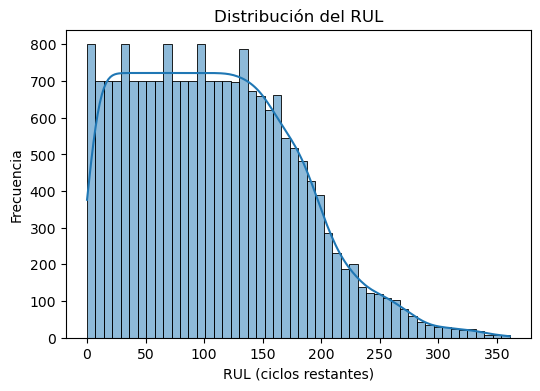

In [8]:
# Gráfico de la distribución del RUL
plt.figure(figsize=(6,4))
sns.histplot(df['RUL'], bins=50, kde=True)
plt.title("Distribución del RUL")
plt.xlabel("RUL (ciclos restantes)")
plt.ylabel("Frecuencia")
plt.show()


El gráfico **Distribución del RUL** refleja una gran acumulación de registros en el rango de los 0 a los 150 ciclos de vida útil restante, lo que proporciona una base de datos robusta para analizar motores en fases avanzadas de uso. La curva desciende de forma notable hacia los 350 ciclos, evidenciando que la mayoría de las unidades fallan mucho antes de alcanzar ese umbral de longevidad, lo que resulta en un histograma con una cola larga hacia la derecha.

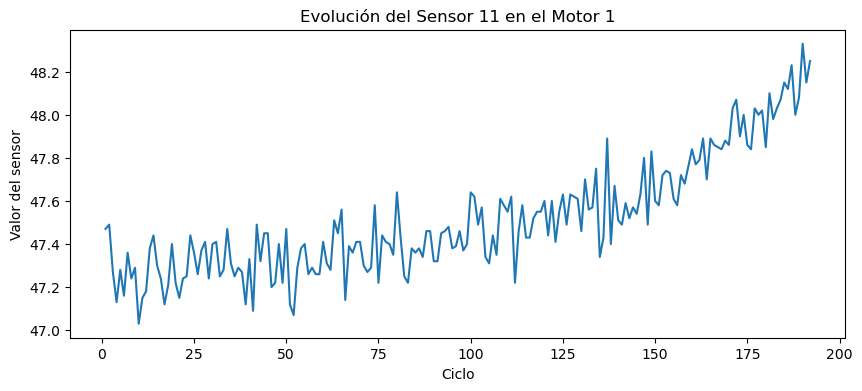

In [9]:
# Gráfico Evolución del Sensor 11 en el Motor 1
motor_1 = df[df['id_motor'] == 1]

plt.figure(figsize=(10,4))
plt.plot(motor_1['ciclo'], motor_1['sensor_11'])
plt.title("Evolución del Sensor 11 en el Motor 1")
plt.xlabel("Ciclo")
plt.ylabel("Valor del sensor")
plt.show()


En el gráfico **Evolución del Sensor 11 en el Motor 1**, se aprecia un comportamiento dinámico donde los valores escalan de forma progresiva desde los 47.2 hasta superar los 48.2 a lo largo de casi 200 ciclos. A pesar de las oscilaciones y el ruido presentes en la medición, la trayectoria ascendente es constante y clara, lo que sugiere que este sensor detecta con precisión el incremento del deterioro mecánico a medida que el motor se aproxima a su límite operativo.

 TOP 3 Sensores que SUBEN cuando el motor falla (Correlación Negativa):
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
Name: RUL, dtype: float64

 TOP 3 Sensores que BAJAN cuando el motor falla (Correlación Positiva):
sensor_16   NaN
sensor_18   NaN
sensor_19   NaN
Name: RUL, dtype: float64


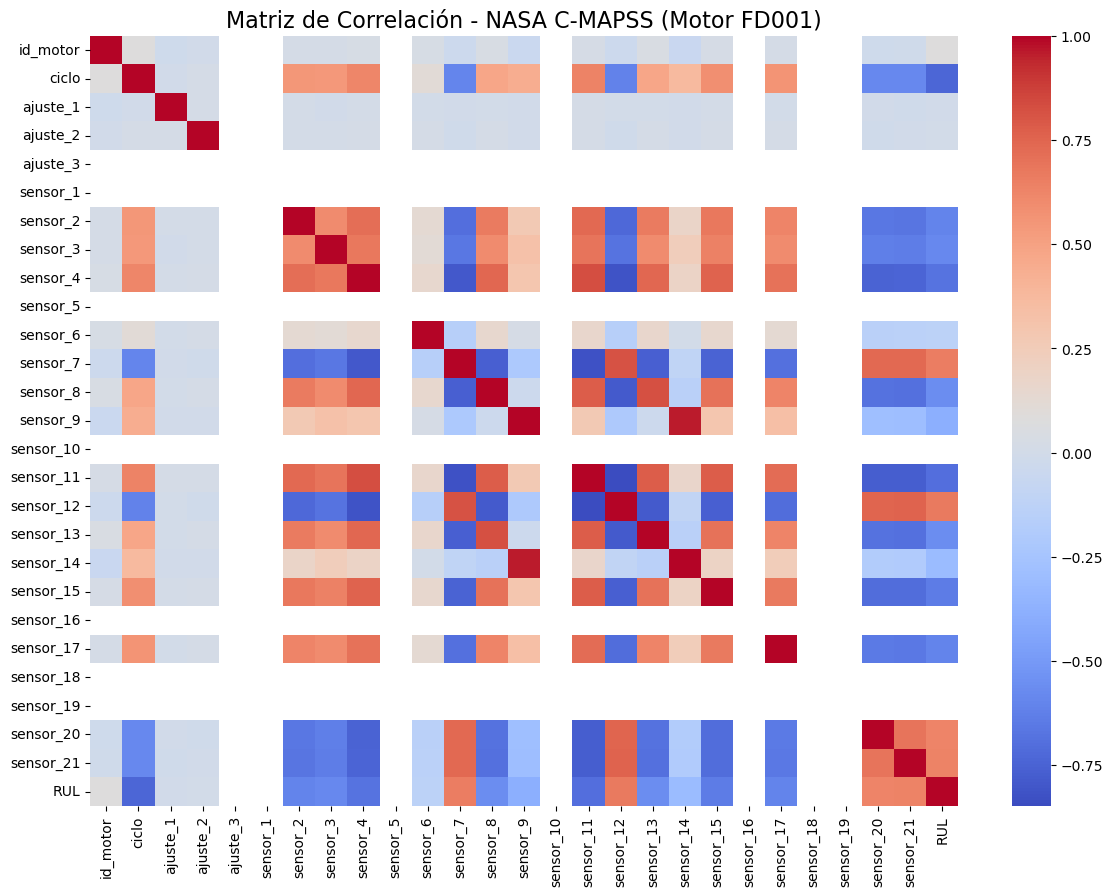

In [10]:
# Calculamos qué sensores están más conectados con el RUL
# Ordenamos los valores de menor a mayor
correlacion_rul = df.corr()['RUL'].drop(['id_motor', 'ciclo', 'RUL']).sort_values()

print(" TOP 3 Sensores que SUBEN cuando el motor falla (Correlación Negativa):")
print(correlacion_rul.head(3))

print("\n TOP 3 Sensores que BAJAN cuando el motor falla (Correlación Positiva):")
print(correlacion_rul.tail(3))

# Hacemos la matriz de correlación
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de Correlación - NASA C-MAPSS (Motor FD001)', fontsize=16)
plt.show()


La **Matriz de Correlación** identifica visualmente qué variables tienen una relación directa con el desgaste del motor. En el desglose superior, se confirma que los sensores 11, 4 y 15 muestran valores que suben a medida que el RUL baja, convirtiéndose en los mejores indicadores para predecir cuándo el motor está cerca de fallar. Por el contrario, la aparición de valores "NaN" para otros sensores confirma que ciertos sensores son constantes.

### 1.4 Eliminación de Sensores Constantes
Durante la revisión inicial se detectan sensores cuyo valor apenas cambia a lo largo del tiempo. Al no aportar información útil sobre la degradación, estos sensores se eliminan del dataset para conservar únicamente variables con variabilidad relevante.

In [11]:
# Limpiamos los sensores que no varían (Varianza Cero)
sensores_constantes = [col for col in df.columns if df[col].nunique() <= 1]
df_limpio = df.drop(columns=sensores_constantes)
df_limpio.head()

,id_motor,ciclo,ajuste_1,ajuste_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


### 1.5 Recorte (Clipping) del RUL
En las primeras fases de operación, los motores presentan valores de RUL muy altos en los que aún no existe degradación observable. Estos valores no aportan información útil y pueden introducir ruido en el entrenamiento.

Para solucionar esto, se aplica una técnica de clipping, estableciendo un límite máximo (techo) al RUL. Con ello, el modelo se centra en la parte del ciclo donde la degradación es realmente detectable por los sensores.


In [12]:
# Aplicamos el techo de 115 ciclos al RUL
MAX_RUL = 115
df_limpio['RUL'] = df_limpio['RUL'].clip(upper=MAX_RUL)
df_limpio.head()

,id_motor,ciclo,ajuste_1,ajuste_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,115
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,115
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,115
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,115
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,115


### 1.5.1 Visualización de la Curva de Degradación
Para comprender el efecto del recorte (clipping) aplicado a la variable objetivo, visualizamos la curva de vida útil (RUL) de un motor específico (Motor 1).

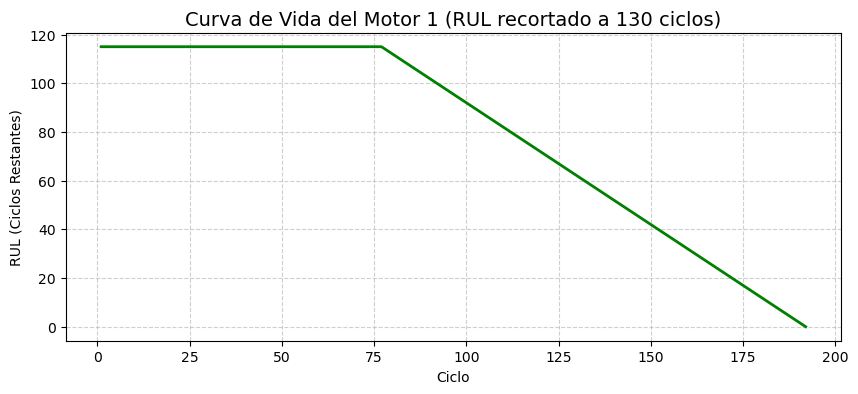

In [13]:
import matplotlib.pyplot as plt

# Seleccionamos solo los datos del Motor 1 para ver su línea de vida
motor_1 = df_limpio[df_limpio['id_motor'] == 1]

plt.figure(figsize=(10, 4))
plt.plot(motor_1['ciclo'], motor_1['RUL'], color='green', linewidth=2)

plt.title('Curva de Vida del Motor 1 (RUL recortado a 115 ciclos)', fontsize=14)
plt.xlabel('Ciclo')
plt.ylabel('RUL (Ciclos Restantes)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

En el gráfico **Curva de Vida del Motor 1 (RUL recortado a 115 ciclos)** se observa cómo el RUL se mantiene plano artificialmente (en 115 ciclos) durante la fase inicial en la que el motor está sano y sus sensores son estables. El declive lineal comienza únicamente en la fase final de degradación. Esta caída (en el ciclo 60) es exactamente la curva que los modelos predictivos de series temporales (como la red neuronal LSTM) aprenderán a estimar para anticipar el fallo.

### 1.6 Suavizado de Ruido (Media Móvil)
Las lecturas de algunos sensores presentan oscilaciones rápidas que dificultan ver la tendencia real de degradación. Para reducir este ruido, se aplica una media móvil de 10 ciclos, calculada por separado para cada motor. Esto permite obtener señales más estables y representativas del comportamiento del sistema.

In [14]:
# Filtramos solo las columnas de los sensores
columnas_sensores = [col for col in df_limpio.columns if 'sensor' in col]

# Aplicamos media móvil de 10 ciclos agrupando por motor
df_limpio[columnas_sensores] = (
    df_limpio.groupby('id_motor')[columnas_sensores]
    .rolling(window=10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

## 1.6.1 Visualización del Suavizado de Sensores
Para demostrar la efectividad de la media móvil en la reducción del ruido de alta frecuencia, comparamos la señal original frente a la señal suavizada de un sensor representativo (en este caso, el sensor_11 del Motor 1).

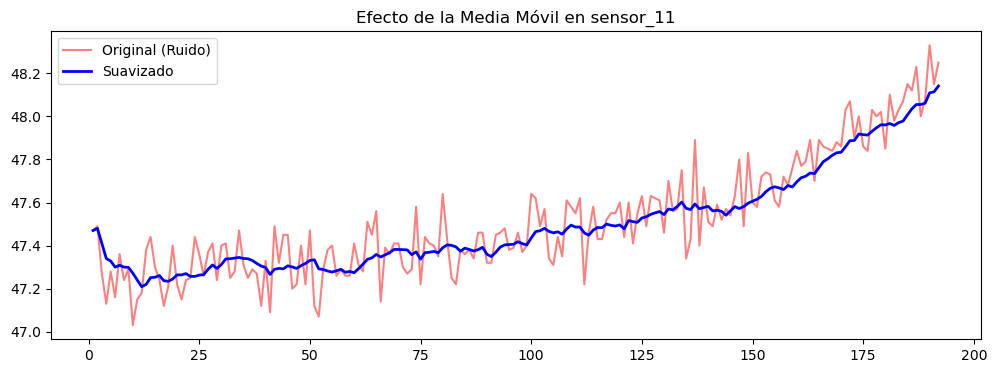

In [15]:
# Graficamos ANTES y DESPUÉS en el mismo gráfico
motor_id = 1
sensor_col = 'sensor_11'

plt.figure(figsize=(12, 4))
plt.plot(df[df['id_motor'] == motor_id]['ciclo'], df[df['id_motor'] == motor_id][sensor_col], color='red', alpha=0.5, label='Original (Ruido)')
plt.plot(df_limpio[df_limpio['id_motor'] == motor_id]['ciclo'], df_limpio[df_limpio['id_motor'] == motor_id][sensor_col], color='blue', linewidth=2, label='Suavizado')
plt.title(f'Efecto de la Media Móvil en {sensor_col}')
plt.legend()
plt.show()

En la gráfica **Efecto de la Media Móvil en sensor 11**, se puede apreciar cómo la línea original presenta continuos picos y caídas abruptas entre ciclos consecutivos. La línea suavizada elimina estas fluctuaciones engañosas, revelando de forma clara la tendencia ascendente real del sensor a medida que el motor acumula desgaste. Esta señal limpia es mucho más óptima para el entrenamiento de la futura red LSTM.

### 1.7 Tratamiento de la Multicolinealidad
El análisis de correlación revela que algunos sensores registran prácticamente la misma señal. Esta redundancia puede afectar al modelo, ya que sobrepondera información duplicada.
Por ello, se eliminan sensores altamente correlacionados entre sí —como sensor_9 y sensor_14— conservando únicamente aquellos que aportan variabilidad real y no repetida al conjunto de datos

In [16]:
# Calculamos la matriz de correlación en valor absoluto
corr_matrix = df_limpio.corr().abs()

# Seleccionamos el triángulo superior de la matriz (para no comparar dos veces)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificamos columnas con correlación superior a 0.98
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]

# Eliminamos solo esas columnas redundantes
df_final = df_limpio.drop(columns=to_drop)

### 1.7.1 Justificación Visual de la Multicolinealidad
La matriz de correlación generada en el análisis exploratorio reveló pares de sensores con una correlación positiva extrema. Para ilustrar por qué se decidió eliminar el sensor_14 en favor del sensor_9, se genera un diagrama de dispersión (scatter plot) entre ambos.


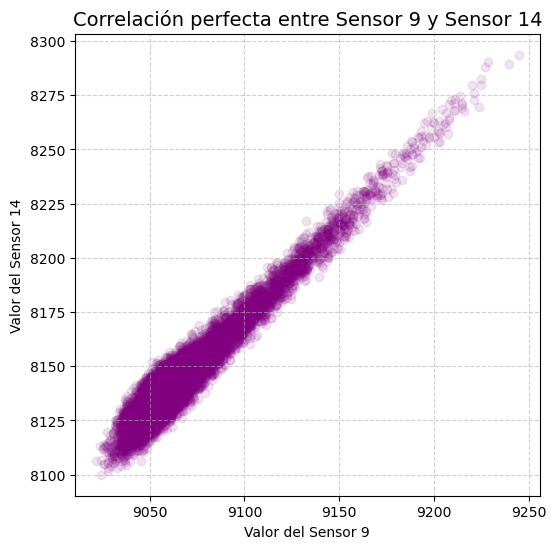

In [17]:
plt.figure(figsize=(6, 6))

# Usamos el df original para ver los valores reales antes de limpiar
plt.scatter(df['sensor_9'], df['sensor_14'], alpha=0.1, color='purple')

plt.title('Correlación perfecta entre Sensor 9 y Sensor 14', fontsize=14)
plt.xlabel('Valor del Sensor 9')
plt.ylabel('Valor del Sensor 14')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

La gráfica **Correlación perfecta entre Sensor 9 y Sensor 14** muestra una línea diagonal casi perfecta. Esto confirma que ambos sensores miden exactamente el mismo fenómeno físico y evolucionan de la misma manera. Incluir ambos en los modelos de Machine Learning (como XGBoost o Random Forest) no aportaría nueva información y podría causar problemas de sobreajuste (overfitting) debido a la multicolinealidad.

### 1.7.2 Ingeniería de Características (Vibración y Tendencia)
Para dotar a los modelos predictivos de mayor contexto temporal, se generan nuevas variables a partir de los sensores más críticos (4, 11, 15 y 21). Por un lado, se calcula la desviación estándar móvil (10 ciclos) para capturar la volatilidad o 'vibración' de la señal. Por otro, se calcula la diferencia respecto a 5 ciclos anteriores para identificar la tendencia o velocidad de degradación.

In [19]:
sensores_para_features = ['sensor_4', 'sensor_11', 'sensor_15', 'sensor_21']

for s in sensores_para_features:
    # Vibración (Desviación estándar de los últimos 10 ciclos)
    df_final[f'{s}_std'] = df_final.groupby('id_motor')[s].transform(lambda x: x.rolling(window=10).std())
    # Tendencia (Diferencia con hace 5 ciclos)
    df_final[f'{s}_diff'] = df_final.groupby('id_motor')[s].diff(periods=5)

df_final.fillna(0, inplace=True)

### 1.8 Normalización de los Datos
Para unificar las escalas de los distintos sensores y evitar que algunas variables dominen sobre otras, se aplica una normalización Min‑Max, llevando todas las lecturas al rango [0, 1].
Esta transformación se realiza únicamente sobre los sensores, manteniendo sin cambios las variables de identificación (id_motor, ciclo) y la variable objetivo (RUL).

In [20]:
df_final.head()

,id_motor,ciclo,ajuste_1,ajuste_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_21,RUL,sensor_4_std,sensor_4_diff,sensor_11_std,sensor_11_diff,sensor_15_std,sensor_15_diff,sensor_21_std,sensor_21_diff
0,1,1,-0.0007,-0.0004,641.820000,1589.700000,1400.600000,21.61,554.360000,2388.0600,...,23.419000,115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2,0.0019,-0.0003,641.985000,1590.760000,1401.870000,21.61,554.055000,2388.0500,...,23.421300,115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,-0.0043,0.0003,642.106667,1589.836667,1402.646667,21.61,554.123333,2388.0600,...,23.395600,115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,4,0.0007,0.0000,642.167500,1588.075000,1402.452500,21.61,554.205000,2388.0725,...,23.390175,115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,5,-0.0019,-0.0002,642.208000,1587.030000,1403.206000,21.61,554.164000,2388.0700,...,23.393020,115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
scaler = MinMaxScaler()

# Seleccionamos los sensores y los ajustes
columnas_a_normalizar = [col for col in df_final.columns if 'sensor' in col or 'ajuste' in col]

# Ajustamos y transformamos los datos sobre el dataframe final
df_final[columnas_a_normalizar] = scaler.fit_transform(df_final[columnas_a_normalizar])

### 1.9 Análisis Estadístico Complementario en R
Utilizando ggplot2, comparamos la distribución de los valores del sensor_11 en dos etapas distintas de la vida de los motores: la etapa inicial (sana) y la etapa final (degradada). Este análisis de densidad confirma que los sensores no solo cambian su valor promedio con el desgaste, sino que también alteran la dispersión de sus lecturas.

In [22]:
# Preparamos los datos en Python para pasarlos a R
# Etiquetamos si el dato es del principio (Sano) o del final (Degradado)
df_r = df_limpio.copy()
df_r['estado'] = ['Sano' if rul > 65 else 'Degradado' for rul in df_r['RUL']]

# Seleccionamos solo el sensor 11 y el estado
datos_r = df_r[['sensor_11', 'estado']]

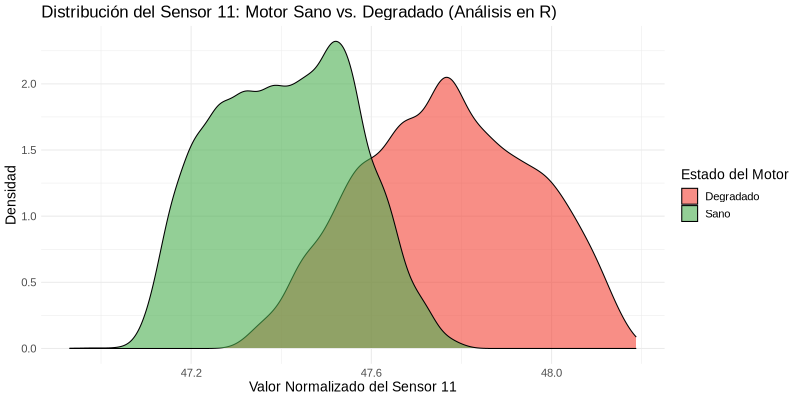

In [23]:
%%R -i datos_r -w 800 -h 400
# El comando %%R indica que esta celda ejecuta código R
# -i datos_r le pasa el dataframe desde Python a R

library(ggplot2)

# Creamos un gráfico de densidad superpuesto
ggplot(datos_r, aes(x=sensor_11, fill=estado)) +
  geom_density(alpha=0.6) +
  scale_fill_manual(values=c("Sano"="#4CAF50", "Degradado"="#F44336")) +
  theme_minimal() +
  labs(title="Distribución del Sensor 11: Motor Sano vs. Degradado (Análisis en R)",
       x="Valor Normalizado del Sensor 11",
       y="Densidad",
       fill="Estado del Motor") +
  theme(text = element_text(size=14))

Este gráfico evalúa la distribución subyacente de las lecturas del Sensor 11, contrastando dos etapas operativas bien diferenciadas: el estado nominal (Sano) y la fase cercana al colapso (Degradado). Se observa un desplazamiento evidente de la masa de probabilidad hacia la derecha, lo que indica un incremento en el valor promedio de la señal. Adicionalmente, el achatamiento y ensanchamiento de la curva roja confirma que los sensores no solo cambian su valor promedio con el desgaste, sino que también alteran la dispersión de sus lecturas.

#### Análisis de Tendencias de Señales (R y ggplot2)
Procedemos a evaluar la tendencia de degradación simultánea de los sensores más correlacionados con el fallo.

Para ello, extraemos una muestra del motor 1 y utilizamos el suavizado estadístico local (LOESS) nativo de R. A diferencia de la media móvil aplicada en el preprocesamiento, LOESS nos permite visualizar la curva de regresión estadística subyacente y su intervalo de confianza, confirmando empíricamente en qué punto exacto del ciclo de vida los sensores comienzan a dispararse o desplomarse de forma crítica.

In [24]:
# Preparamos los datos en Python: cogemos 3 sensores clave del Motor 1
df_r_tendencia = df_limpio[df_limpio['id_motor'] == 1][['ciclo', 'sensor_11', 'sensor_4', 'sensor_21']]

# Usamos 'melt' de pandas para poner los datos en formato largo (ideal para R)
df_r_largo = df_r_tendencia.melt(id_vars=['ciclo'], var_name='sensor', value_name='valor')

`geom_smooth()` using formula = 'y ~ x'


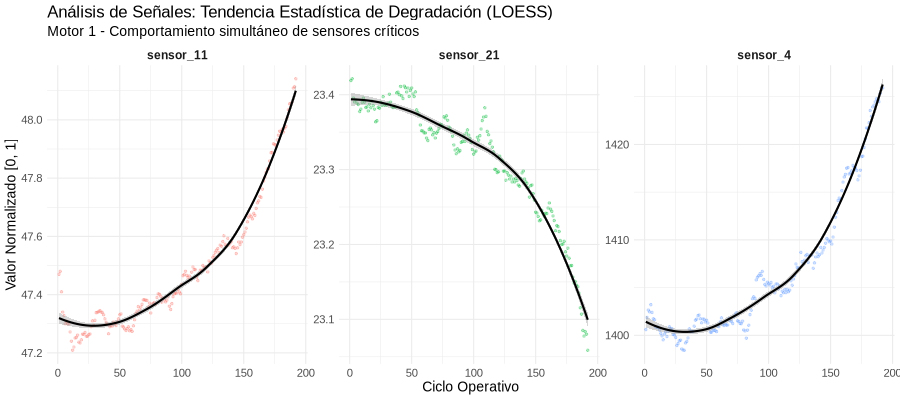

In [25]:
%%R -i df_r_largo -w 900 -h 400

library(ggplot2)

# Creamos un gráfico de facetas (uno para cada sensor) con su línea de tendencia
ggplot(df_r_largo, aes(x=ciclo, y=valor, color=sensor)) +
  geom_point(alpha=0.3, size=1) +  # Puntos reales
  geom_smooth(method="loess", se=TRUE, color="black", linewidth=1) + # Tendencia estadística
  facet_wrap(~sensor, scales="free_y") + # Separa en 3 gráficos
  theme_minimal() +
  labs(title="Análisis de Señales: Tendencia Estadística de Degradación (LOESS)",
       subtitle="Motor 1 - Comportamiento simultáneo de sensores críticos",
       x="Ciclo Operativo",
       y="Valor Normalizado [0, 1]") +
  theme(legend.position="none",
        strip.text = element_text(size=12, face="bold"),
        text = element_text(size=14))

La visualización por facetas nos permite evaluar el comportamiento simultáneo de los sensores más correlacionados con el fallo (11, 21 y 4) a lo largo de todo el ciclo operativo de un motor de muestra. La aplicación de la técnica de suavizado estadístico local (LOESS) aísla el ruido de alta frecuencia para revelar la curva de regresión real. Esta proyección confirma empíricamente en qué punto exacto del ciclo de vida los sensores pierden su estabilidad inicial y comienzan a dispararse (sensores 11 y 4) o a desplomarse (sensor 21) de forma crítica, evidenciando el inicio de la degradación inercial.

#### Análisis de Varianza por Etapa Operativa (R + ggplot2)
Para finalizar el análisis estadístico, se evalúa la dispersión de las señales en función de la etapa de vida del motor. Este análisis es fundamental para justificar el uso de modelos de aprendizaje profundo, ya que la variabilidad de los datos (el "ruido" estadístico) tiende a aumentar significativamente a medida que el sistema se aproxima al punto de fallo.

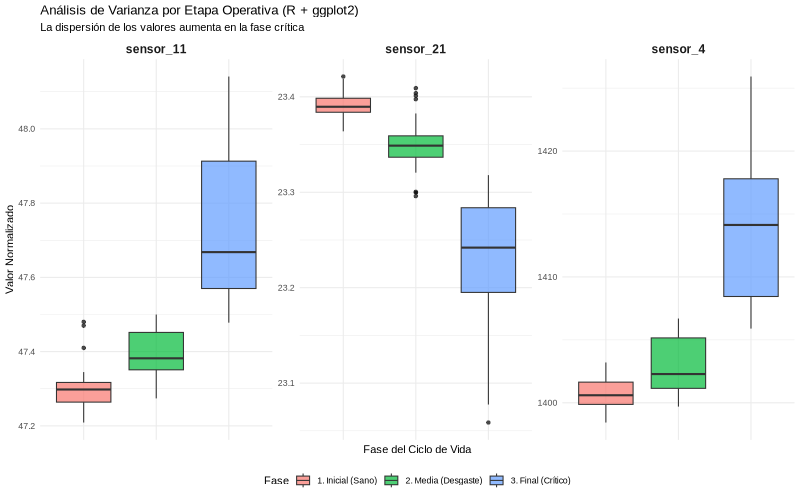

In [26]:
%%R -i df_r_largo -w 800 -h 500

library(ggplot2)

# Definimos tres etapas de vida del motor basadas en el ciclo
df_r_largo$fase_vida <- ifelse(df_r_largo$ciclo < 50, "1. Inicial (Sano)",
                        ifelse(df_r_largo$ciclo < 120, "2. Media (Desgaste)",
                               "3. Final (Crítico)"))

# Creamos boxplots para ver cómo cambia la dispersión del dato en cada fase
ggplot(df_r_largo, aes(x=fase_vida, y=valor, fill=fase_vida)) +
  geom_boxplot(alpha=0.7, outlier.shape = 21, outlier.fill = "black", outlier.size = 1.5) +
  facet_wrap(~sensor, scales="free_y") +
  theme_minimal() +
  labs(title="Análisis de Varianza por Etapa Operativa (R + ggplot2)",
       subtitle="La dispersión de los valores aumenta en la fase crítica",
       x="Fase del Ciclo de Vida",
       y="Valor Normalizado",
       fill="Fase") +
  theme(legend.position="bottom",
        strip.text = element_text(size=12, face="bold"),
        axis.text.x = element_blank(), # Quitamos texto del eje X porque ya está en la leyenda
        axis.ticks.x = element_blank())

Mediante el uso de diagramas de cajas (boxplots), se cuantifica la dispersión de las señales dividiendo la vida útil del sistema en tres fases discretas: Inicial (Sano), Media (Desgaste) y Final (Crítico). Se evidencia una expansión progresiva tanto del rango intercuartílico (la caja) como de los valores extremos en la etapa final. Este análisis demuestra que la variabilidad de los datos (el "ruido" estadístico) tiende a aumentar significativamente a medida que el sistema se aproxima al punto de fallo. Esta alta volatilidad en los últimos ciclos justifica plenamente la necesidad de integrar arquitecturas predictivas complejas que no dependan de umbrales estáticos simples.

### 1.10 Exportación del Dataset Final

El dataset limpio, normalizado y con el RUL calculado se guarda como un archivo procesado. Este será el punto de entrada para:
* **Random Forest** y **XGBoost**.
* **Autoencoder** y **LSTM** (Redes Neuronales).
* **El simulador IoT** (fuente de entrada de datos)

In [29]:
# Guardamos el dataset procesado
df_final.to_csv('NASA_C-MAPSS/train_FD001_procesado.csv', index=False)

Para cumplir con las buenas prácticas de MLOps y los requisitos de la arquitectura, versionamos nuestro dataset procesado final utilizando **DVC** (Data Version Control). Esto nos garantiza la reproducibilidad de los modelos y evita sobrecargar el repositorio Git con archivos pesados.

Los comandos ejecutados en la terminal del proyecto para trackear este archivo han sido:
```bash
# 1. Inicializamos DVC en la raíz del proyecto
dvc init

# 2. Añadimos el archivo procesado para que DVC lo vigile
dvc add NASA_C-MAPSS/train_FD001_procesado.csv

# 3. DVC genera un archivo .dvc ligero. Ese es el que subimos a Git.
git add NASA_C-MAPSS/train_FD001_procesado.csv.dvc .gitignore
git commit -m "Versionado del dataset limpio y normalizado FD001"

### 1.11 Versionado de Datos con DVC
El manejo de conjuntos de datos de gran volumen en repositorios como Git resulta ineficiente y compromete el rendimiento del sistema. Además, los estándares de MLOps exigen garantizar la reproducibilidad exacta de los experimentos vinculando cada modelo a una versión concreta de los datos.

Para solventar esta limitación, se integra la herramienta DVC (Data Version Control). Este sistema permite realizar un seguimiento del dataset procesado de forma independiente, generando un archivo de referencia ligero (.dvc) que es el que finalmente se almacena en el control de versiones, manteniendo el archivo físico de gran tamaño fuera del repositorio.

Los comandos ejecutados en la terminal del proyecto para trackear este archivo han sido:
```bash
# 1. Inicializamos DVC en la raíz del proyecto
dvc init

# 2. Añadimos el archivo procesado para que DVC lo vigile
dvc add NASA_C-MAPSS/train_FD001_procesado.csv

# 3. DVC genera un archivo .dvc ligero. Ese es el que subimos a Git.
git add NASA_C-MAPSS/train_FD001_procesado.csv.dvc .gitignore
git commit -m "Versionado del dataset limpio y normalizado FD001"
```

In [30]:
#!dvc init
#!dvc add NASA_C-MAPSS/train_FD001_procesado.csv
#!git add NASA_C-MAPSS/train_FD001_procesado.csv.dvc .gitignore
#!git commit -m "Versionado del dataset procesado FD001"

### 1.12 Pipeline de Inferencia: Preprocesamiento del Dataset de Test

Una vez definido y validado nuestro flujo de limpieza con los datos de entrenamiento, es imperativo aplicar **exactamente las mismas transformaciones** al conjunto de datos de prueba (`test_FD001.txt`). 

Realizar este proceso dentro del mismo cuaderno garantiza que mantenemos un único "Pipeline de Preprocesamiento", asegurando que los modelos evaluados en las siguientes fases no sufran errores por desajuste de dimensionalidad ni problemas de *Data Leakage* (fuga de información).

**Pasos clave aplicados a los datos nuevos:**
1. **Reducción de Dimensionalidad:** Eliminación estricta de los mismos sensores constantes y redundantes que se descartaron en el conjunto de entrenamiento.
2. **Suavizado:** Aplicación de la media móvil de 5 ciclos por motor.
3. **Escalado Consistente:** Normalización de las características utilizando el método `.transform()` (y no `.fit_transform()`). Este detalle técnico es crucial en Machine Learning, ya que asegura que los datos nuevos se escalan utilizando los valores mínimos y máximos aprendidos exclusivamente durante la fase de entrenamiento, simulando un entorno real de producción.

In [31]:
# Cargamos el archivo original de texto de Test
df_test = pd.read_csv('NASA_C-MAPSS/test_FD001.txt', sep=r'\s+', header=None, names=nombres_columnas)

# Limpiamos los sensores que no varían (Varianza Cero)
df_test_limpio = df_test.drop(columns=sensores_constantes)

# Aplicamos media móvil de 10 ciclos agrupando por motor
df_test_limpio[columnas_sensores] = (
    df_test_limpio.groupby('id_motor')[columnas_sensores]
    .rolling(window=10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Eliminamos solo esas columnas redundantes
df_test_final = df_test_limpio.drop(columns=to_drop)

# Añadimos las nuevas características (Vibración y Tendencia)
for s in sensores_para_features:
    # 1. Volatilidad (std)
    df_test_final[f'{s}_std'] = df_test_final.groupby('id_motor')[s].transform(lambda x: x.rolling(window=10).std())
    # 2. Tendencia (diff)
    df_test_final[f'{s}_diff'] = df_test_final.groupby('id_motor')[s].diff(periods=5)

# Rellenamos los huecos iniciales para que no haya errores en el modelo
df_test_final.fillna(0, inplace=True)

# Actualizamos la lista de columnas para incluir las nuevas en la normalización
columnas_actualizadas = [col for col in df_test_final.columns if 'sensor' in col or 'ajuste' in col]

# Transformamos los datos sobre el dataframe final (Usando solo transform)
df_test_final[columnas_actualizadas] = scaler.transform(df_test_final[columnas_actualizadas])

# Guardamos el dataset procesado
df_test_final.to_csv('NASA_C-MAPSS/test_FD001_procesado.csv', index=False)

print("Dataset de Test procesado y guardado en: NASA_C-MAPSS/test_FD001_procesado.csv")
df_test_final.head()

Dataset de Test procesado y guardado en: NASA_C-MAPSS/test_FD001_procesado.csv


,id_motor,ciclo,ajuste_1,ajuste_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_20,sensor_21,sensor_4_std,sensor_4_diff,sensor_11_std,sensor_11_diff,sensor_15_std,sensor_15_diff,sensor_21_std,sensor_21_diff
0,1,1,0.632184,0.750000,0.655806,0.365255,0.251125,1.0,0.654199,0.306122,...,0.541387,0.675728,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
1,1,2,0.344828,0.250000,0.382206,0.412288,0.218778,1.0,0.765937,0.267857,...,0.630872,0.693910,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
2,1,3,0.517241,0.583333,0.395433,0.412983,0.253753,1.0,0.745158,0.289116,...,0.683072,0.716714,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
3,1,4,0.741379,0.500000,0.399958,0.392344,0.300689,1.0,0.732416,0.286990,...,0.686801,0.706568,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
4,1,5,0.580460,0.500000,0.408521,0.398238,0.307981,1.0,0.729005,0.275510,...,0.686801,0.716272,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
